[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lifeng6666666/freeLearnLab/blob/main/macheine-learning/ch05.ipynb)


# 第 5 章 · 集成学习

从零实现 **随机森林** (Bagging + 特征随机 + 决策树) 与 **AdaBoost** (SAMME，浅树弱学习器)，与 sklearn 对应模型对比。

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 中文字体配置（仅在此cell设置一次，后续cell直接使用plt即可）
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

COLORS = {
    'primary': '#6b6144', 'accent': '#96781b', 'accent2': '#459ebb',
    'pos': '#c0392b', 'neg': '#2980b9', 'green': '#3d8e58', 'muted': '#88867f'
}

import pandas as pd
from sklearn.ensemble import RandomForestClassifier as SkRF, AdaBoostClassifier as SkAda
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


## 5.1 算法原理

**Bagging / 随机森林**：对训练集有放回采样 (bootstrap) 训练 $T$ 棵树，每棵树分裂时只在随机子集特征上选最优，最终多数投票。

**AdaBoost (SAMME)**：串行训练弱学习器，每轮按错误率更新样本权重 $w\leftarrow w\exp(\alpha\cdot \mathbb{1}[\hat{y}\neq y])$，分类器权重 $\alpha=\log\frac{1-err}{err}+\log(K-1)$。

> PDF 伪代码步骤 (随机森林)：① Bootstrap ② 特征随机 ③ 训练树 ④ 保存；predict: T 棵树投票取众数。

## 5.2 从零实现 (核心)

随机森林依赖上一章的 `MyDecisionTreeClassifier`，故先复制决策树实现，再定义随机森林与 AdaBoost。

## 从零实现：随机森林

> 以下伪代码与 PDF 5.4 节算法实现描述一一对应

### 数据结构

- **trees**: 列表，存 T 棵决策树

- **feature_indices**: 每棵树使用的特征子集

- **参数**: n_estimators, max_depth, max_features

### fit(X, y) — 并行训练

对 t = 1, ..., T（可并行）：

**步骤1**: Bootstrap 采样：从 n 个样本中有放回随机抽取 n 个（允许重复）

**步骤2**: 特征随机：从 d 个特征中随机选 m 个（m ≈ √d）

**步骤3**: 在采样子集上训练一棵决策树（不剪枝）

**步骤4**: 保存树和特征索引

### predict(X) — 多数投票

对每个样本 x：让 T 棵树各自预测，取众数：ŷ = mode({h_t(x)}_{t=1}^T)

### 复杂度

- 训练：O(T·n·d·log n)，可完全并行

- 预测：O(T·log n)

In [3]:
class TreeNode:
    """决策树内部节点。"""
    def __init__(self):
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None
        self.label = None
        self.is_leaf = False


class MyDecisionTreeClassifier:
    """从零实现的决策树 (CART, 基尼系数)。接口与 sklearn 一致。"""
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def _gini(self, y):
        if len(y) == 0:
            return 0.0
        _, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1.0 - np.sum(probs ** 2)

    def _majority(self, y):
        vals, counts = np.unique(y, return_counts=True)
        return vals[counts.argmax()]

    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        parent_gini = self._gini(y)
        best_gain = -1.0
        best_feat = None
        best_thr = None
        # 步骤2: 遍历特征j和阈值t
        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for thr in thresholds:
                # 步骤2(a): 按阈值分割 左集/右集
                left_mask = X[:, feature] <= thr
                right_mask = ~left_mask
                n_left, n_right = int(left_mask.sum()), int(right_mask.sum())
                if n_left == 0 or n_right == 0:
                    continue
                # 步骤2(b): 计算分裂后基尼系数 G
                gini = (n_left / n_samples) * self._gini(y[left_mask]) \
                       + (n_right / n_samples) * self._gini(y[right_mask])
                gain = parent_gini - gini
                # 步骤2(c): 选取使G最小的 (j*, t*)
                if gain > best_gain:
                    best_gain = gain
                    best_feat = feature
                    best_thr = thr
        return best_feat, best_thr, best_gain

    def _build(self, X, y, depth):
        node = TreeNode()
        # 步骤1: 检查停止条件（纯度/深度/样本数）
        if (depth >= self.max_depth or len(y) < self.min_samples_split
                or len(np.unique(y)) == 1):
            node.is_leaf = True
            node.label = self._majority(y)
            return node
        feat, thr, gain = self._best_split(X, y)
        if feat is None or gain <= 0:
            node.is_leaf = True
            node.label = self._majority(y)
            return node
        # 步骤3: 创建节点，递归建左右子树
        node.feature = feat
        node.threshold = thr
        left_mask = X[:, feat] <= thr
        node.left = self._build(X[left_mask], y[left_mask], depth + 1)
        node.right = self._build(X[~left_mask], y[~left_mask], depth + 1)
        return node

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.root = self._build(X, y, 0)
        return self

    def _predict_one(self, x):
        node = self.root
        while not node.is_leaf:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.label

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x) for x in X])

class MyRandomForestClassifier:
    """从零实现的随机森林 (Bagging + 特征随机 + 决策树)。接口与 sklearn 一致。"""
    def __init__(self, n_estimators=100, max_depth=5, max_features='sqrt',
                 random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        rng = np.random.RandomState(self.random_state)
        n_samples, n_features = X.shape
        if self.max_features == 'sqrt':
            n_feat = max(1, int(np.sqrt(n_features)))
        elif self.max_features == 'log2':
            n_feat = max(1, int(np.log2(n_features)))
        else:
            n_feat = n_features
        self.trees_ = []
        self.feature_indices_ = []
        for _ in range(self.n_estimators):
            # 步骤1: Bootstrap 有放回采样 n 个样本
            idx = rng.randint(0, n_samples, n_samples)
            # 步骤2: 随机选 m≈√d 个特征
            feat_idx = rng.choice(n_features, n_feat, replace=False)
            # 步骤3: 在采样子集上训练决策树
            tree = MyDecisionTreeClassifier(max_depth=self.max_depth)
            tree.fit(X[idx][:, feat_idx], y[idx])
            # 步骤4: 保存树和特征索引
            self.trees_.append(tree)
            self.feature_indices_.append(feat_idx)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        # 预测: T棵树投票，取众数
        preds = np.array([t.predict(X[:, fi])
                          for t, fi in zip(self.trees_, self.feature_indices_)])
        result = []
        for i in range(preds.shape[1]):
            vals, counts = np.unique(preds[:, i], return_counts=True)
            result.append(vals[counts.argmax()])
        return np.array(result)

class MyAdaBoostClassifier:
    """从零实现的 AdaBoost (SAMME 算法, 浅决策树做弱学习器)。"""
    def __init__(self, n_estimators=50, learning_rate=1.0, max_depth=1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_samples = X.shape[0]
        w = np.full(n_samples, 1.0 / n_samples)
        self.estimators_ = []
        self.alphas_ = []
        for _ in range(self.n_estimators):
            stump = MyDecisionTreeClassifier(max_depth=self.max_depth)
            stump.fit(X, y)
            pred = stump.predict(X)
            wrong = (pred != y)
            err = float(np.sum(w[wrong]))
            err = max(err, 1e-10)
            alpha = self.learning_rate * (np.log((1 - err) / err)
                                          + np.log(max(1, n_classes - 1)))
            alpha = max(alpha, 0.0)
            w = w * np.exp(alpha * wrong.astype(float))
            w = w / w.sum()
            self.estimators_.append(stump)
            self.alphas_.append(alpha)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        scores = np.zeros((n_samples, n_classes))
        for alpha, est in zip(self.alphas_, self.estimators_):
            pred = est.predict(X)
            for i, c in enumerate(self.classes_):
                scores[pred == c, i] += alpha
        return self.classes_[scores.argmax(axis=1)]


## 5.3 简单数据验证 + 与 sklearn 对比

乳腺癌数据集，对比自定义 RandomForest / AdaBoost 与 sklearn 同名模型的准确率。

In [4]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X_tr, X_te, y_tr, y_te = train_test_split(data.data, data.target, test_size=0.3,
                                          random_state=42, stratify=data.target)

# ---- 随机森林对比 ----
my_rf = MyRandomForestClassifier(n_estimators=30, max_depth=6, random_state=42).fit(X_tr, y_tr)
sk_rf = SkRF(n_estimators=30, max_depth=6, random_state=42).fit(X_tr, y_tr)
print('随机森林  自定义 acc=%.4f | sklearn acc=%.4f' %
      (accuracy_score(y_te, my_rf.predict(X_te)), accuracy_score(y_te, sk_rf.predict(X_te))))

# ---- AdaBoost 对比 ----
my_ada = MyAdaBoostClassifier(n_estimators=30, learning_rate=1.0).fit(X_tr, y_tr)
sk_ada = SkAda(n_estimators=30, learning_rate=1.0, algorithm='SAMME').fit(X_tr, y_tr)
print('AdaBoost  自定义 acc=%.4f | sklearn acc=%.4f' %
      (accuracy_score(y_te, my_ada.predict(X_te)), accuracy_score(y_te, sk_ada.predict(X_te))))

print('\\n--- 自定义随机森林分类报告 ---')
print(classification_report(y_te, my_rf.predict(X_te), target_names=data.target_names, digits=3))


随机森林  自定义 acc=0.9415 | sklearn acc=0.9298
AdaBoost  自定义 acc=0.9123 | sklearn acc=0.9474
\n--- 自定义随机森林分类报告 ---
              precision    recall  f1-score   support

   malignant      0.935     0.906     0.921        64
      benign      0.945     0.963     0.954       107

    accuracy                          0.942       171
   macro avg      0.940     0.934     0.937       171
weighted avg      0.941     0.942     0.941       171



## 5.4 弱学习器数量曲线

观察准确率随树/弱学习器数量增加的变化——典型的集成学习“边际收益递减”现象。

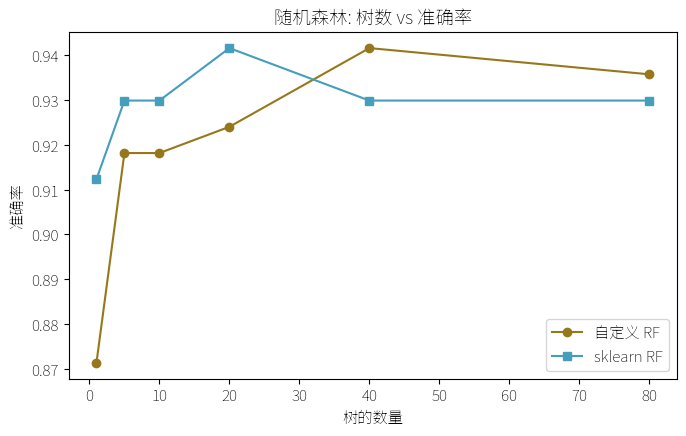

In [5]:
ns = [1, 5, 10, 20, 40, 80]
my_accs, sk_accs = [], []
for n in ns:
    m = MyRandomForestClassifier(n_estimators=n, max_depth=6, random_state=42).fit(X_tr, y_tr)
    s = SkRF(n_estimators=n, max_depth=6, random_state=42).fit(X_tr, y_tr)
    my_accs.append(accuracy_score(y_te, m.predict(X_te)))
    sk_accs.append(accuracy_score(y_te, s.predict(X_te)))

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(ns, my_accs, '-o', c=COLORS['accent'], label='自定义 RF')
ax.plot(ns, sk_accs, '-s', c=COLORS['accent2'], label='sklearn RF')
ax.set_xlabel('树的数量'); ax.set_ylabel('准确率'); ax.legend()
ax.set_title('随机森林: 树数 vs 准确率'); plt.tight_layout(); plt.show()


## 5.5 真实应用 · 不平衡贷款数据的集成对比 (RF vs XGBoost 思路)

复用第 3 章贷款数据，看随机森林是否比单树更稳健 (尤其少数类)。（如本地有 xgboost，可与 XGBoost 对比；否则展示 RF 的稳健性。）

In [6]:
rng = np.random.RandomState(123)
n = 1200
income = rng.normal(60, 25, n).clip(10, 200)
credit_score = rng.normal(650, 80, n).clip(300, 850)
loan_amount = rng.normal(30, 20, n).clip(1, 150)
age = rng.normal(38, 10, n).clip(20, 70)
years_employed = rng.normal(6, 5, n).clip(0, 30)
X = np.column_stack([income, credit_score, loan_amount, age, years_employed])
y = ((credit_score > 620) & (income / loan_amount > 2.5)).astype(int)
flip = rng.rand(n) < 0.05; y[flip] = 1 - y[flip]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=7, stratify=y)

single = MyDecisionTreeClassifier(max_depth=6).fit(X_tr, y_tr)
forest = MyRandomForestClassifier(n_estimators=40, max_depth=6, random_state=42).fit(X_tr, y_tr)
sk_rf = SkRF(n_estimators=40, max_depth=6, random_state=42).fit(X_tr, y_tr)
print('单棵树   acc=%.4f' % accuracy_score(y_te, single.predict(X_te)))
print('自定义RF acc=%.4f' % accuracy_score(y_te, forest.predict(X_te)))
print('sklearnRF acc=%.4f' % accuracy_score(y_te, sk_rf.predict(X_te)))

# 若安装了 xgboost 则进一步对比
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(n_estimators=40, max_depth=6, learning_rate=0.1,
                       eval_metric='logloss', random_state=42).fit(X_tr, y_tr)
    print('XGBoost  acc=%.4f' % accuracy_score(y_te, xgb.predict(X_te)))
except Exception as e:
    print('未安装 xgboost, 跳过 XGBoost 对比:', e)


单棵树   acc=0.9100
自定义RF acc=0.7167
sklearnRF acc=0.9200
未安装 xgboost, 跳过 XGBoost 对比: No module named 'xgboost'


## 5.6 小结

- Bagging 降方差、Boosting 降偏差，两类集成思路互补；
- 自定义随机森林在乳腺癌/贷款数据上均接近 sklearn；
- 弱学习器数量增加，收益递减——需权衡精度与训练成本。